# US Commercial Prescription Analytics & Market Access Dashboard

## Exploratory Data Analysis (EDA)

Author: Nikhil Matade

Tools Used:
- PostgreSQL
- Python
- Pandas
- Matplotlib
- Seaborn
- Plotly

Business Domain:
Commercial Pharmaceutical Analytics

Data Source:
CMS Medicare Part D

In [ ]:
# ===============================================================
# IMPORTING LIBRARIES
# ===============================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sqlalchemy import create_engine

# Display Settings

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)

plt.style.use('ggplot')

plt.rcParams['figure.figsize']=(10,6)

sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# ===============================================================
# CONNECTING TO POSTGRESQL
# ===============================================================

from sqlalchemy import create_engine

username = "postgres"

password = "123456"

host = "localhost"

port = "5432"

database = "pharma_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

print("Database Connected Successfully")

Database Connected Successfully


In [ ]:

# ===============================================================
# Loading the Provider Dataset
# ===============================================================

provider = pd.read_sql("""

SELECT

"PRSCRBR_NPI",
"Prscrbr_Type",
"Prscrbr_State_Abrvtn",
"Tot_Clms",
"Tot_Drug_Cst",
"Tot_Benes",

cost_per_claim,
avg_cost_per_beneficiary,
drug_cost_category,
prescription_category,
specialty_group

FROM commercial.provider_features

LIMIT 50000;

""", engine)

provider.shape

(50000, 11)

In [ ]:
# ===============================================================
# Loading the Geography Dataset
# ===============================================================

geography = pd.read_sql("""
SELECT
    "Prscrbr_Geo_Desc",
    "Prscrbr_Geo_Lvl",
    "Brnd_Name",
    "Gnrc_Name",
    "Tot_Prscrbrs",
    "Tot_Clms",
    "Tot_Drug_Cst",
    "Tot_Benes",
    cost_per_claim,
    drug_cost_category,
    prescription_category
FROM commercial.geography_features;
""", engine)

print(geography.shape)

(117660, 11)


In [ ]:
# ===============================================================
# Loading the Spending Dataset
# ===============================================================

spending = pd.read_sql("""
SELECT
    "Brnd_Name",
    "Gnrc_Name",
    "Mftr_Name",
    "Tot_Spndng_2024",
    "Tot_Clms_2024",
    "Tot_Benes_2024",
    cost_per_claim_2024,
    cost_per_beneficiary_2024,
    spending_category,
    market_share_percentage
FROM commercial.spending_features;
""", engine)

print("Spending dataset loaded successfully!")
print("Shape:", spending.shape)

Spending dataset loaded successfully!
Shape: (14536, 10)


In [ ]:
# First Five Rows of Provider 
provider.head()

,PRSCRBR_NPI,Prscrbr_Type,Prscrbr_State_Abrvtn,Tot_Clms,Tot_Drug_Cst,Tot_Benes,cost_per_claim,avg_cost_per_beneficiary,drug_cost_category,prescription_category,specialty_group
0,1083802128,Psychiatry & Neurology,AP,20,323.37,12.0,16.17,26.95,Low,Low,Psychiatry
1,1003002312,Rheumatology,MA,2984,869791.60,252.0,291.49,3451.55,High,High,Other
2,1003004201,Internal Medicine,TX,7482,996979.52,489.0,133.25,2038.81,High,High,Internal Medicine
3,1003007592,Physician Assistant,PA,4473,494528.21,257.0,110.56,1924.23,High,High,Other
4,1003007907,Pulmonary Disease,OR,1589,1171090.55,276.0,737.00,4243.08,High,High,Other


In [ ]:
# First Five Rows of Geography
geography.head()

,Prscrbr_Geo_Desc,Prscrbr_Geo_Lvl,Brnd_Name,Gnrc_Name,Tot_Prscrbrs,Tot_Clms,Tot_Drug_Cst,Tot_Benes,cost_per_claim,drug_cost_category,prescription_category
0,National,National,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",442,965,26074.56,451.0,27.02,Low,Medium
1,National,National,1st Tier Unifine Pentips,"Pen Needle, Diabetic",209,378,10454.60,213.0,27.66,Low,Low
2,National,National,Tricare,Prenatal Vit103/Iron Fum/Folic,17,21,1105.37,19.0,52.64,Low,Low
3,National,National,Stalevo 200,Carbidopa/Levodopa/Entacapone,13,41,41016.44,12.0,1000.40,Low,Low
4,National,National,Ropivacaine Hcl,Ropivacaine Hcl/Pf,13,31,3907.60,16.0,126.05,Low,Low


In [ ]:
# First Five Rows of Spending
spending.head()

,Brnd_Name,Gnrc_Name,Mftr_Name,Tot_Spndng_2024,Tot_Clms_2024,Tot_Benes_2024,cost_per_claim_2024,cost_per_beneficiary_2024,spending_category,market_share_percentage
0,Abacavir-Lamivudine,Abacavir Sulfate/Lamivudine,Laurus Labs Lim,344076.05,1007,395.0,341.68,871.08,Low,0.00
1,Daptomycin,Daptomycin,Xellia Pharmace,31733701.86,35150,9328.0,902.81,3401.98,High,0.01
2,Daptomycin,Daptomycin,Dr.Reddy'S Lab,2761074.61,5924,1773.0,466.08,1557.29,Medium,0.00
3,Daptomycin,Daptomycin,Meitheal Pharma,2216978.23,11755,3179.0,188.60,697.38,Medium,0.00
4,Daptomycin,Daptomycin,Northstar Rx Ll,11387866.31,6534,1778.0,1742.86,6404.87,High,0.00


In [ ]:
# Dataset Shape
print("Provider :",provider.shape)
print("Geography :",geography.shape)
print("Spending :",spending.shape)

Provider : (50000, 11)
Geography : (117660, 11)
Spending : (14536, 10)


In [ ]:
# Column Names Provider
provider.columns

Index(['PRSCRBR_NPI', 'Prscrbr_Type', 'Prscrbr_State_Abrvtn', 'Tot_Clms',
       'Tot_Drug_Cst', 'Tot_Benes', 'cost_per_claim',
       'avg_cost_per_beneficiary', 'drug_cost_category',
       'prescription_category', 'specialty_group'],
      dtype='str')

In [ ]:
# Column Names Geography
geography.columns

Index(['Prscrbr_Geo_Desc', 'Prscrbr_Geo_Lvl', 'Brnd_Name', 'Gnrc_Name',
       'Tot_Prscrbrs', 'Tot_Clms', 'Tot_Drug_Cst', 'Tot_Benes',
       'cost_per_claim', 'drug_cost_category', 'prescription_category'],
      dtype='str')

In [ ]:
# Column Names Spending 
spending.columns

Index(['Brnd_Name', 'Gnrc_Name', 'Mftr_Name', 'Tot_Spndng_2024',
       'Tot_Clms_2024', 'Tot_Benes_2024', 'cost_per_claim_2024',
       'cost_per_beneficiary_2024', 'spending_category',
       'market_share_percentage'],
      dtype='str')

In [21]:
provider.dtypes

PRSCRBR_NPI                     str
Prscrbr_Type                    str
Prscrbr_State_Abrvtn            str
Tot_Clms                      int64
Tot_Drug_Cst                float64
Tot_Benes                   float64
cost_per_claim              float64
avg_cost_per_beneficiary    float64
drug_cost_category              str
prescription_category           str
specialty_group                 str
dtype: object

In [22]:
geography.dtypes

Prscrbr_Geo_Desc             str
Prscrbr_Geo_Lvl              str
Brnd_Name                    str
Gnrc_Name                    str
Tot_Prscrbrs               int64
Tot_Clms                   int64
Tot_Drug_Cst             float64
Tot_Benes                float64
cost_per_claim           float64
drug_cost_category           str
prescription_category        str
dtype: object

In [23]:
spending.dtypes

Brnd_Name                        str
Gnrc_Name                        str
Mftr_Name                        str
Tot_Spndng_2024              float64
Tot_Clms_2024                  int64
Tot_Benes_2024               float64
cost_per_claim_2024          float64
cost_per_beneficiary_2024    float64
spending_category                str
market_share_percentage      float64
dtype: object

# Missing Values

In [24]:
provider.isnull().sum().sort_values(ascending=False)

Tot_Benes                   405
avg_cost_per_beneficiary    405
PRSCRBR_NPI                   0
Prscrbr_State_Abrvtn          0
Prscrbr_Type                  0
Tot_Drug_Cst                  0
Tot_Clms                      0
cost_per_claim                0
drug_cost_category            0
prescription_category         0
specialty_group               0
dtype: int64

In [25]:
geography.isnull().sum().sort_values(ascending=False)

Tot_Benes                21951
Prscrbr_Geo_Lvl              0
Prscrbr_Geo_Desc             0
Brnd_Name                    0
Gnrc_Name                    0
Tot_Clms                     0
Tot_Prscrbrs                 0
Tot_Drug_Cst                 0
cost_per_claim               0
drug_cost_category           0
prescription_category        0
dtype: int64

In [26]:
spending.isnull().sum().sort_values(ascending=False)

cost_per_beneficiary_2024    782
Tot_Benes_2024               782
Gnrc_Name                      0
Brnd_Name                      0
Tot_Spndng_2024                0
Mftr_Name                      0
Tot_Clms_2024                  0
cost_per_claim_2024            0
spending_category              0
market_share_percentage        0
dtype: int64

# Duplicate Rows

In [27]:
provider.duplicated().sum()

np.int64(0)

In [28]:
geography.duplicated().sum()

np.int64(0)

In [29]:
spending.duplicated().sum()

np.int64(0)

# Summary Statistics

In [30]:
provider.describe().T

,count,mean,std,min,25%,50%,75%,max
Tot_Clms,50000.0,4880.789400,5.344218e+03,11.00,2141.000,3425.000,5910.00,244919.00
Tot_Drug_Cst,50000.0,715633.065853,1.147342e+06,0.20,217903.220,418041.715,804644.66,51563207.39
Tot_Benes,49595.0,474.439883,1.499518e+03,11.00,256.000,396.000,585.00,183252.00
cost_per_claim,50000.0,191.906898,4.089732e+02,0.01,70.030,96.330,154.76,25229.29
avg_cost_per_beneficiary,49595.0,1865.826843,3.383603e+03,2.48,672.345,1125.800,1847.75,105930.22


In [31]:
geography.describe().T

,count,mean,std,min,25%,50%,75%,max
Tot_Prscrbrs,117660.0,1.674479e+03,1.535997e+04,1.00,13.0000,62.000,432.0000,7.639410e+05
Tot_Clms,117660.0,2.908394e+04,4.947276e+05,11.00,52.0000,284.000,2572.2500,7.332621e+07
Tot_Drug_Cst,117660.0,4.900466e+06,1.004434e+08,16.30,16668.5625,122036.385,782990.4525,2.076927e+10
Tot_Benes,95709.0,1.072355e+04,1.478125e+05,11.00,38.0000,173.000,1331.0000,1.782480e+07
cost_per_claim,117660.0,2.800399e+03,9.287979e+03,1.12,42.7175,207.825,1099.4025,6.639874e+05


In [32]:
spending.describe().T

,count,mean,std,min,25%,50%,75%,max
Tot_Spndng_2024,14536.0,3.971764e+07,3.936576e+08,3.91,36932.4625,673478.235,5.862205e+06,2.077493e+10
Tot_Clms_2024,14536.0,2.355059e+05,1.526969e+06,11.00,253.0000,2931.500,3.750700e+04,7.334903e+07
Tot_Benes_2024,13754.0,8.134447e+04,4.383451e+05,11.00,141.0000,1293.000,1.504925e+04,1.783081e+07
cost_per_claim_2024,14536.0,2.275769e+03,1.066530e+04,0.28,24.6875,95.240,5.769525e+02,4.078512e+05
cost_per_beneficiary_2024,13754.0,1.072051e+04,5.382652e+04,1.50,56.5625,234.600,1.619267e+03,1.488217e+06
market_share_percentage,14536.0,6.503165e-03,6.825767e-02,0.00,0.0000,0.000,0.000000e+00,3.600000e+00


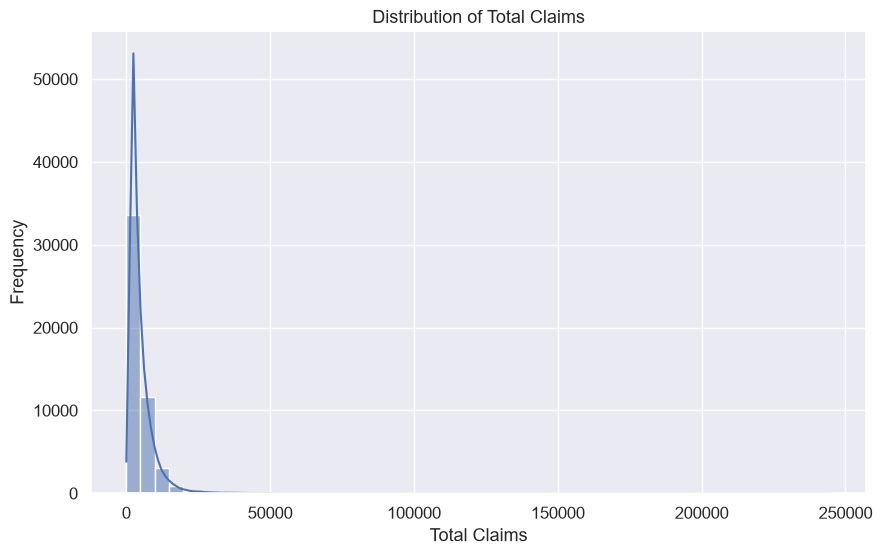

In [ ]:
# ------------------------------------------------
# Chart: Distribution of Total Claims
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.histplot(
    provider["Tot_Clms"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Claims")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")

plt.show()

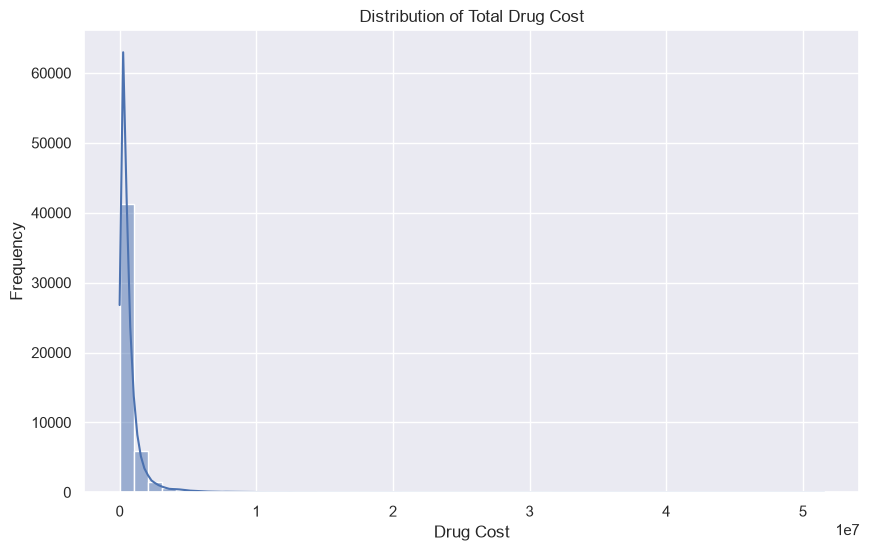

In [ ]:
# ------------------------------------------------
# Distribution of Drug Cost
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.histplot(
    provider["Tot_Drug_Cst"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Drug Cost")
plt.xlabel("Drug Cost")
plt.ylabel("Frequency")

plt.show()

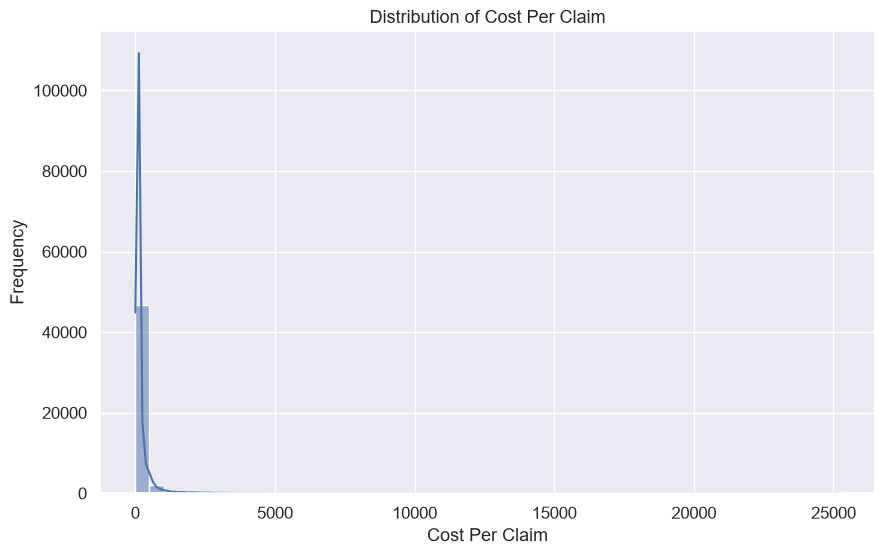

In [ ]:
# ------------------------------------------------
# Distribution of Cost Per Claim
# ------------------------------------------------
plt.figure(figsize=(10, 6))

sns.histplot(
    provider["cost_per_claim"],  # Changed to lowercase
    bins=50,
    kde=True
)

plt.title("Distribution of Cost Per Claim")
plt.xlabel("Cost Per Claim")
plt.ylabel("Frequency")

plt.show()

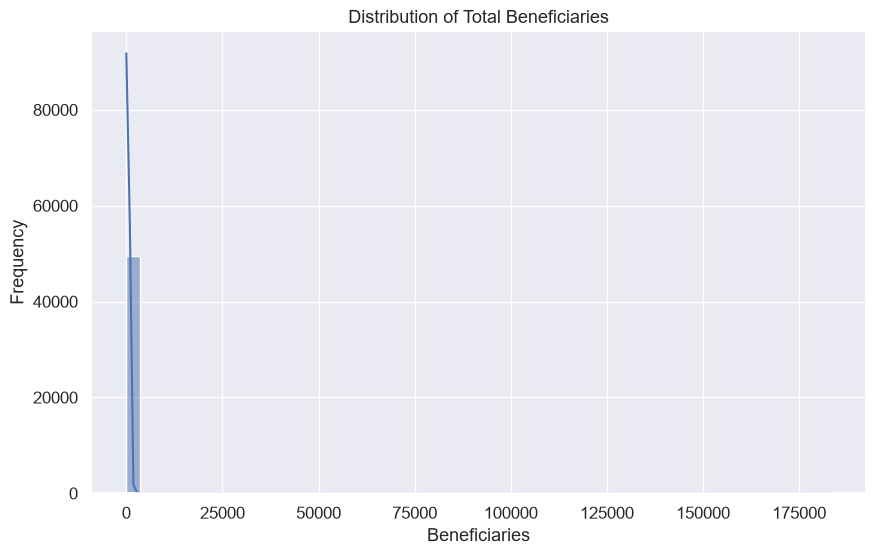

In [ ]:
# ------------------------------------------------
# Distribution of Beneficiaries
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.histplot(
    provider["Tot_Benes"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Beneficiaries")
plt.xlabel("Beneficiaries")
plt.ylabel("Frequency")

plt.show()

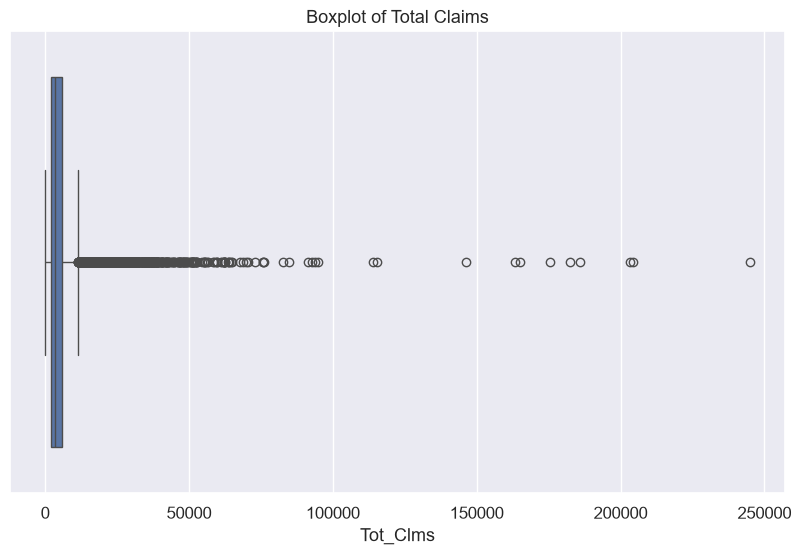

In [ ]:
# ------------------------------------------------
# Boxplot - Total Claims
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.boxplot(
    x=provider["Tot_Clms"]
)

plt.title("Boxplot of Total Claims")

plt.show()

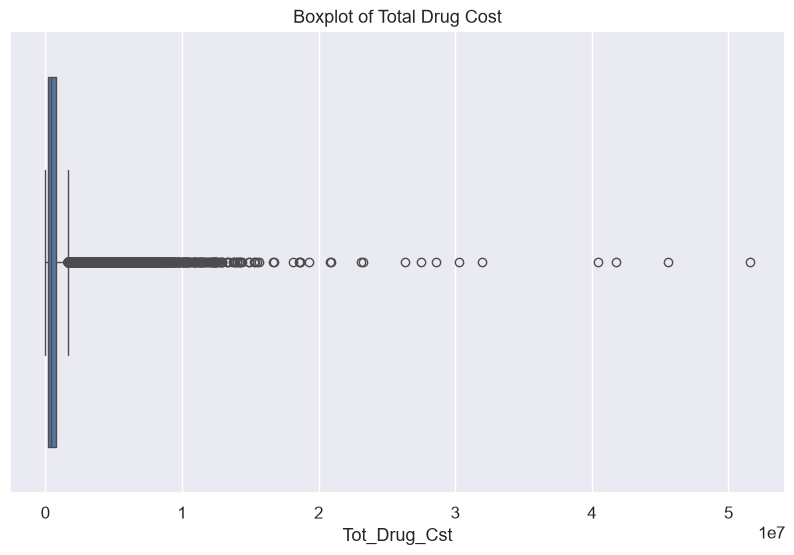

In [ ]:
# ------------------------------------------------
# Boxplot - Drug Cost
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.boxplot(
    x=provider["Tot_Drug_Cst"]
)

plt.title("Boxplot of Total Drug Cost")

plt.show()

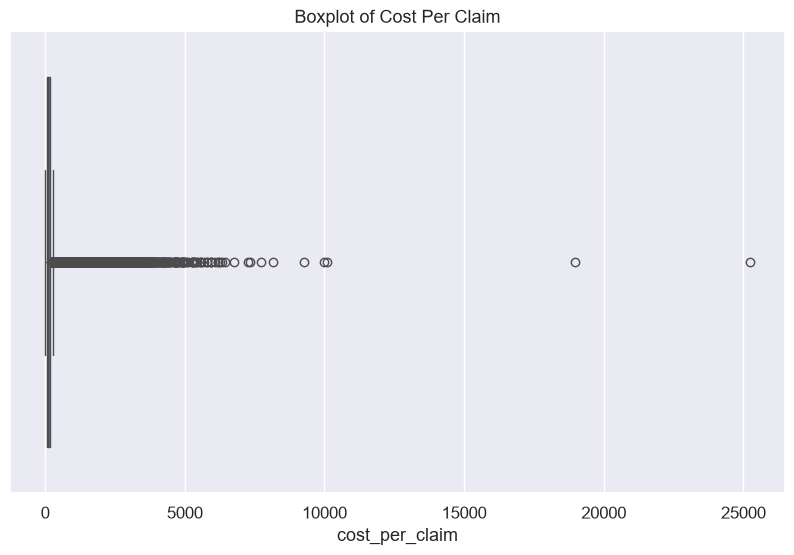

In [ ]:
# ------------------------------------------------
# Boxplot - Cost Per Claim
# ------------------------------------------------
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=provider["cost_per_claim"]  # Changed to lowercase
)

plt.title("Boxplot of Cost Per Claim")

plt.show()

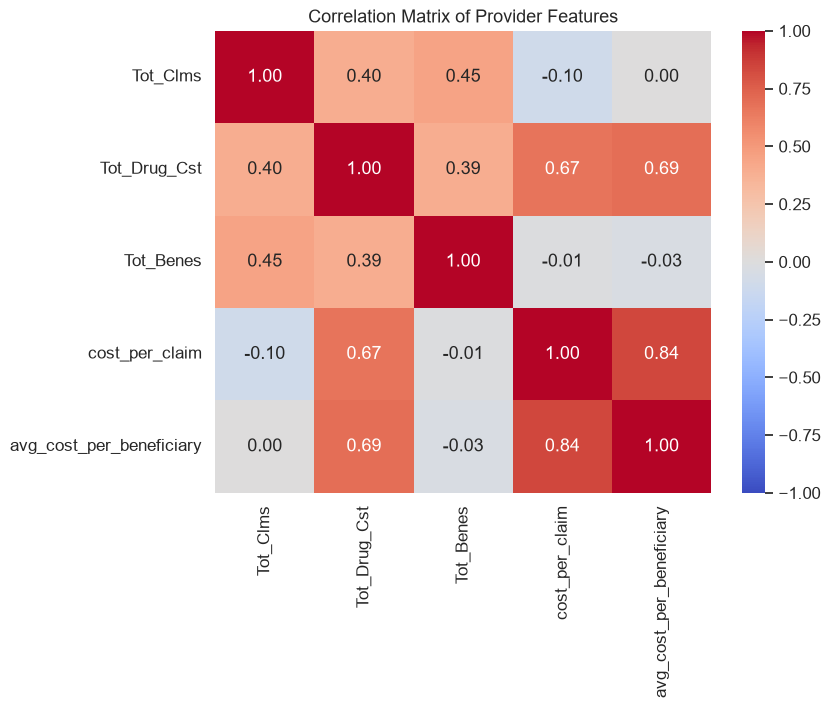

In [ ]:
# ------------------------------------------------
# Correlation Matrix
# ------------------------------------------------
corr = provider[
    [
        "Tot_Clms",
        "Tot_Drug_Cst",
        "Tot_Benes",
        "cost_per_claim",             # Changed to lowercase
        "avg_cost_per_beneficiary"    # Changed to lowercase
    ]
].corr()

# Let's display it nicely with a heatmap!
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Provider Features")
plt.show()

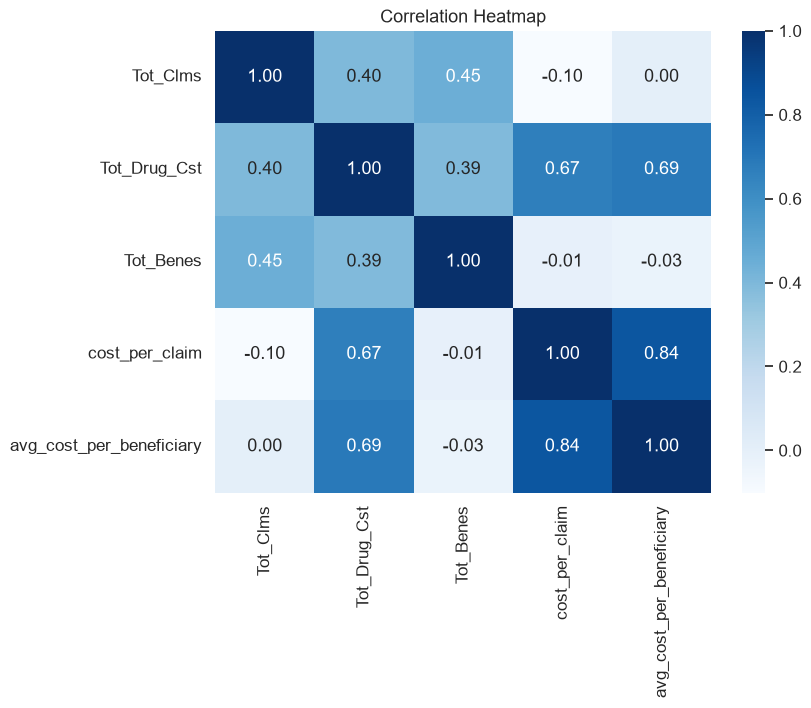

In [ ]:
# ------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# ------------------------------------------------
# Importing libraries
# ------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set(font_scale=1.0)

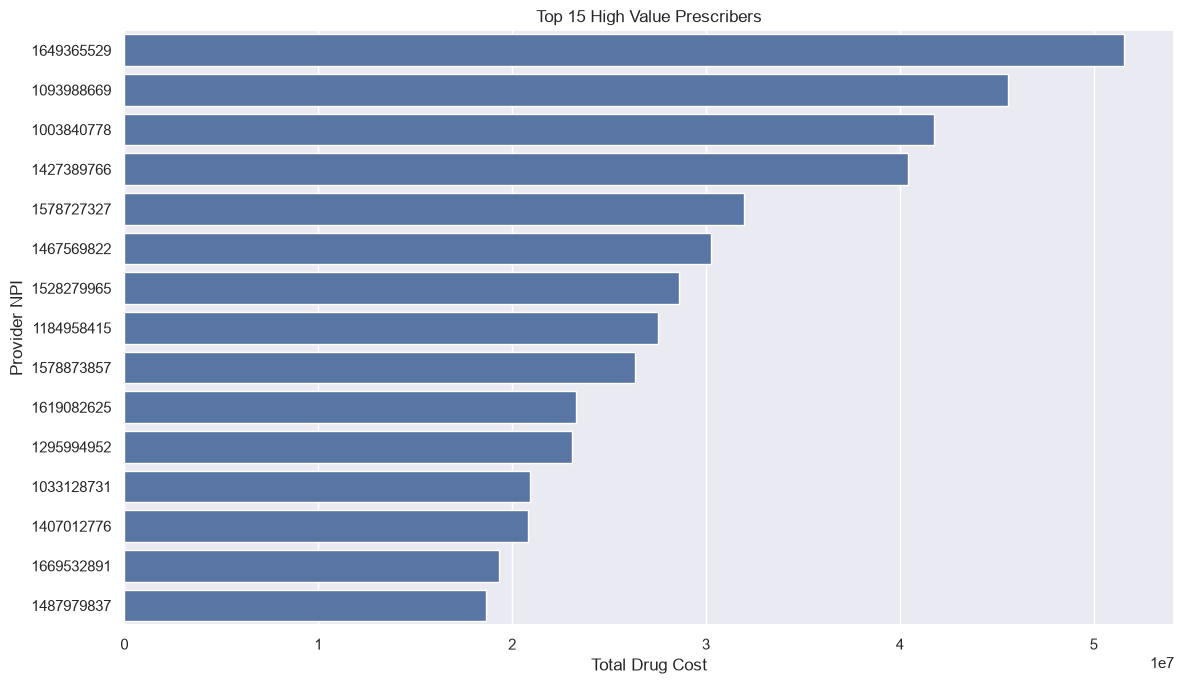

In [ ]:
# Top 15 High Value Prescribers
top_provider = provider.nlargest(
    15,
    "Tot_Drug_Cst"
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_provider,
    x="Tot_Drug_Cst",
    y="PRSCRBR_NPI"
)

plt.title("Top 15 High Value Prescribers")

plt.xlabel("Total Drug Cost")

plt.ylabel("Provider NPI")

plt.tight_layout()

plt.show()

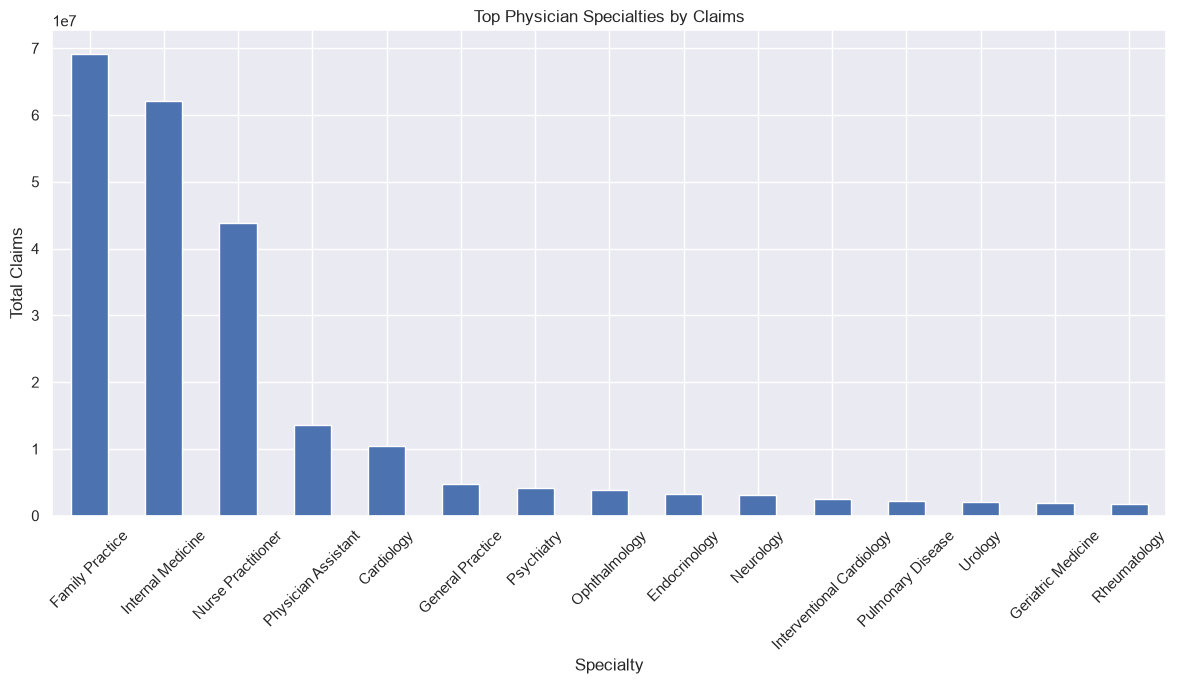

In [ ]:
# ------------------------------------------------
# Top Physician Specialties
# ------------------------------------------------
specialty = (
provider
.groupby("Prscrbr_Type")["Tot_Clms"]
.sum()
.sort_values(ascending=False)
.head(15)
)

plt.figure(figsize=(12,7))

specialty.plot(kind="bar")

plt.title("Top Physician Specialties by Claims")

plt.xlabel("Specialty")

plt.ylabel("Total Claims")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

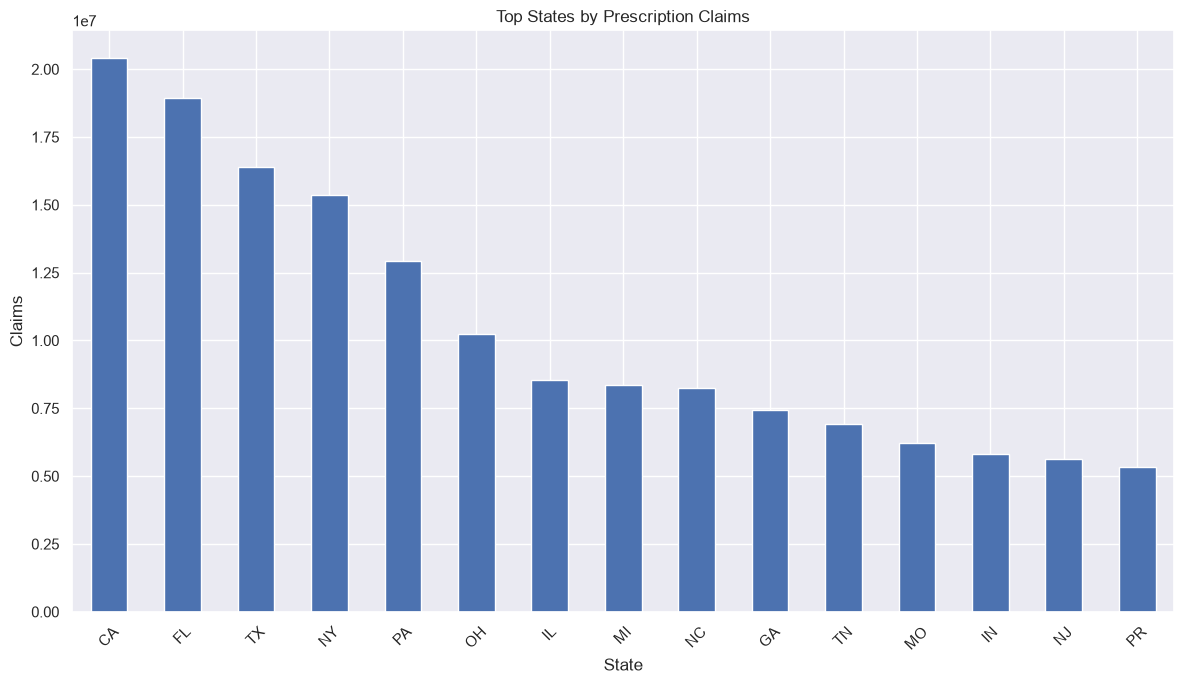

In [ ]:
# ------------------------------------------------
# Top States
# ------------------------------------------------
state = (
provider
.groupby("Prscrbr_State_Abrvtn")["Tot_Clms"]
.sum()
.sort_values(ascending=False)
.head(15)
)

plt.figure(figsize=(12,7))

state.plot(kind="bar")

plt.title("Top States by Prescription Claims")

plt.xlabel("State")

plt.ylabel("Claims")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

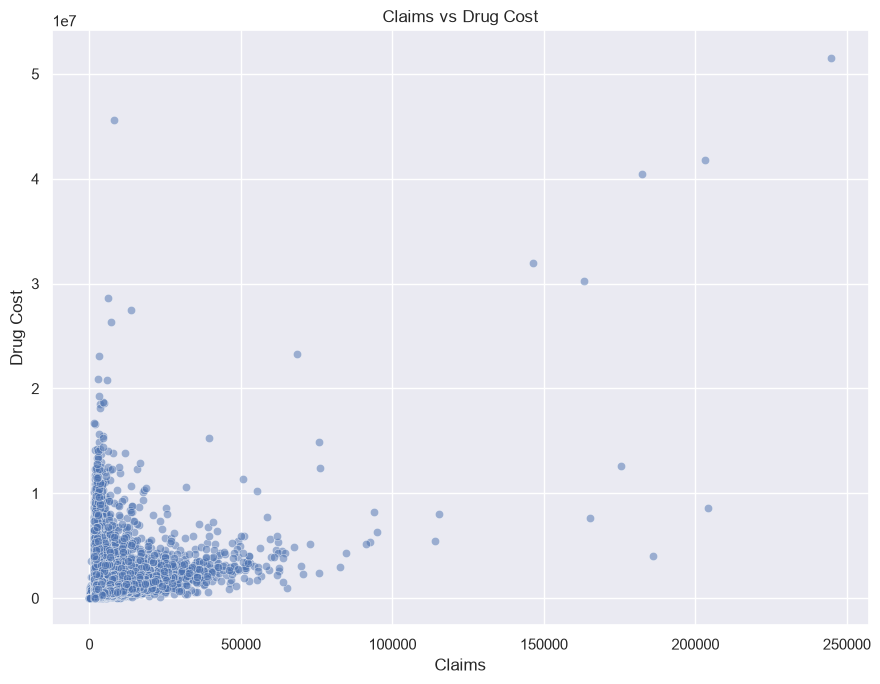

In [ ]:
# ------------------------------------------------
# Claims vs Drug Cost
# ------------------------------------------------
plt.figure(figsize=(9,7))

sns.scatterplot(

data=provider,

x="Tot_Clms",

y="Tot_Drug_Cst",

alpha=.5

)

plt.title("Claims vs Drug Cost")

plt.xlabel("Claims")

plt.ylabel("Drug Cost")

plt.tight_layout()

plt.show()

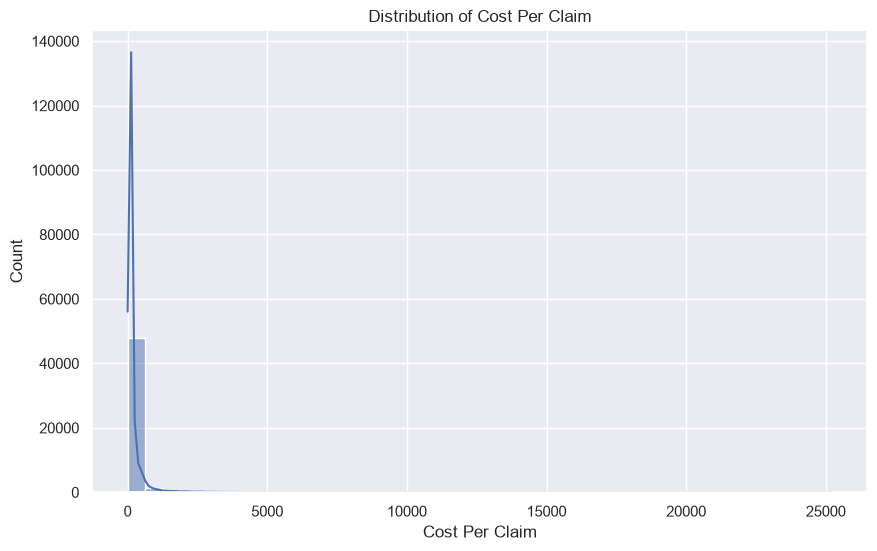

In [ ]:
# ------------------------------------------------
# Cost Per Claim Distribution
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.histplot(

provider["cost_per_claim"],

bins=40,

kde=True

)

plt.title("Distribution of Cost Per Claim")

plt.xlabel("Cost Per Claim")

plt.show()

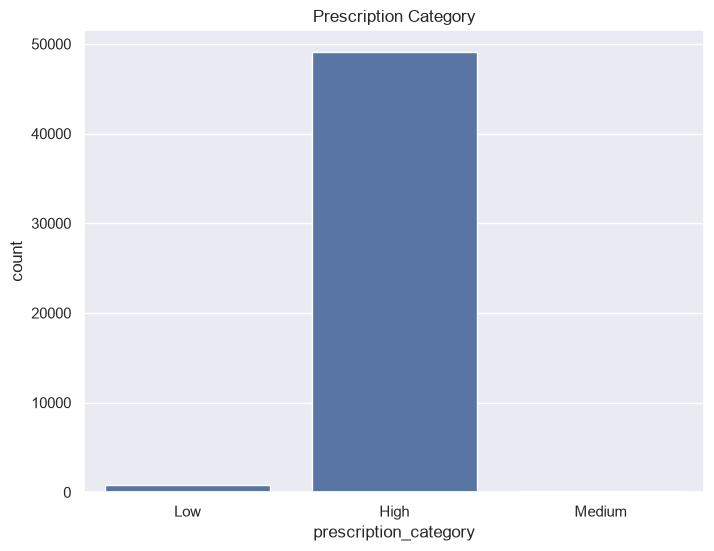

In [ ]:
# ------------------------------------------------
# Prescription Category
# ------------------------------------------------
plt.figure(figsize=(8,6))

sns.countplot(

data=provider,

x="prescription_category"

)

plt.title("Prescription Category")

plt.show()

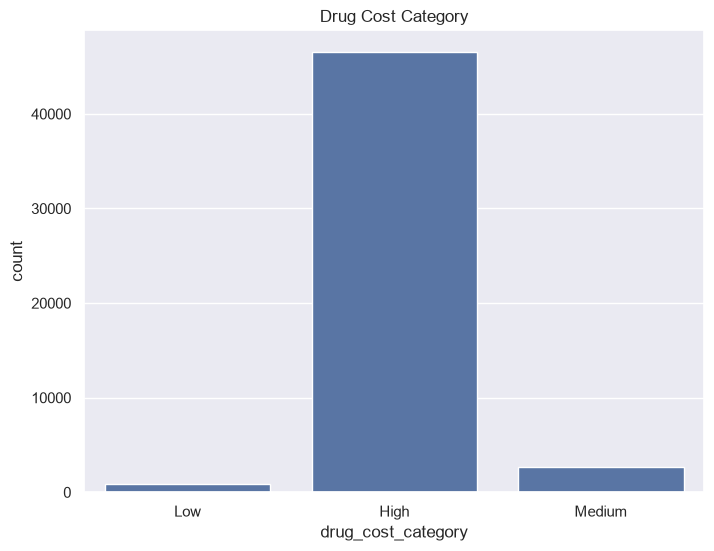

In [ ]:
# ------------------------------------------------
# Drug Cost Category
# ------------------------------------------------
plt.figure(figsize=(8,6))

sns.countplot(

data=provider,

x="drug_cost_category"

)

plt.title("Drug Cost Category")

plt.show()

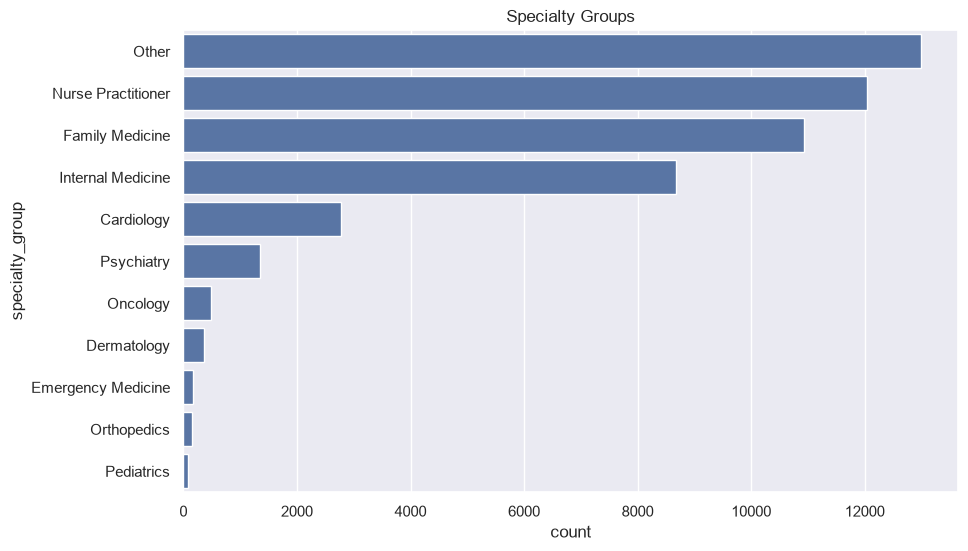

In [ ]:
# ------------------------------------------------
# Specialty Group
# ------------------------------------------------
plt.figure(figsize=(10,6))

sns.countplot(

data=provider,

y="specialty_group",

order=provider["specialty_group"].value_counts().index

)

plt.title("Specialty Groups")

plt.show()

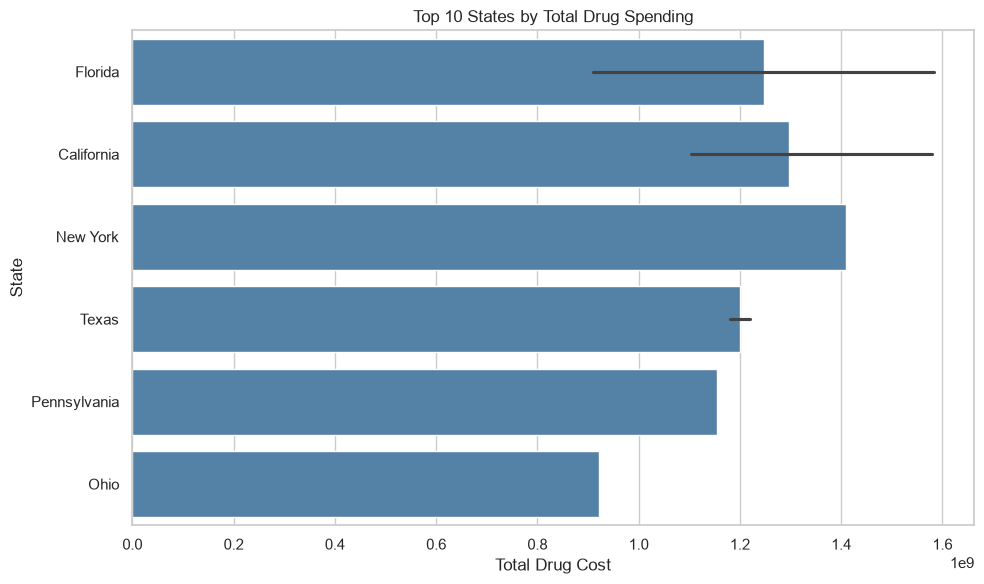

In [ ]:
# ------------------------------------------------
# Top States by Drug Cost
# ------------------------------------------------
geo_clean = geography[geography["Prscrbr_Geo_Desc"] != "National"]

top_states = geo_clean.sort_values(by="Tot_Drug_Cst", ascending=False).head(10)

# 3. Create a simple bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x="Tot_Drug_Cst",
    y="Prscrbr_Geo_Desc",
    color="steelblue"  
)

plt.title("Top 10 States by Total Drug Spending")
plt.xlabel("Total Drug Cost")
plt.ylabel("State")

plt.tight_layout()
plt.show()

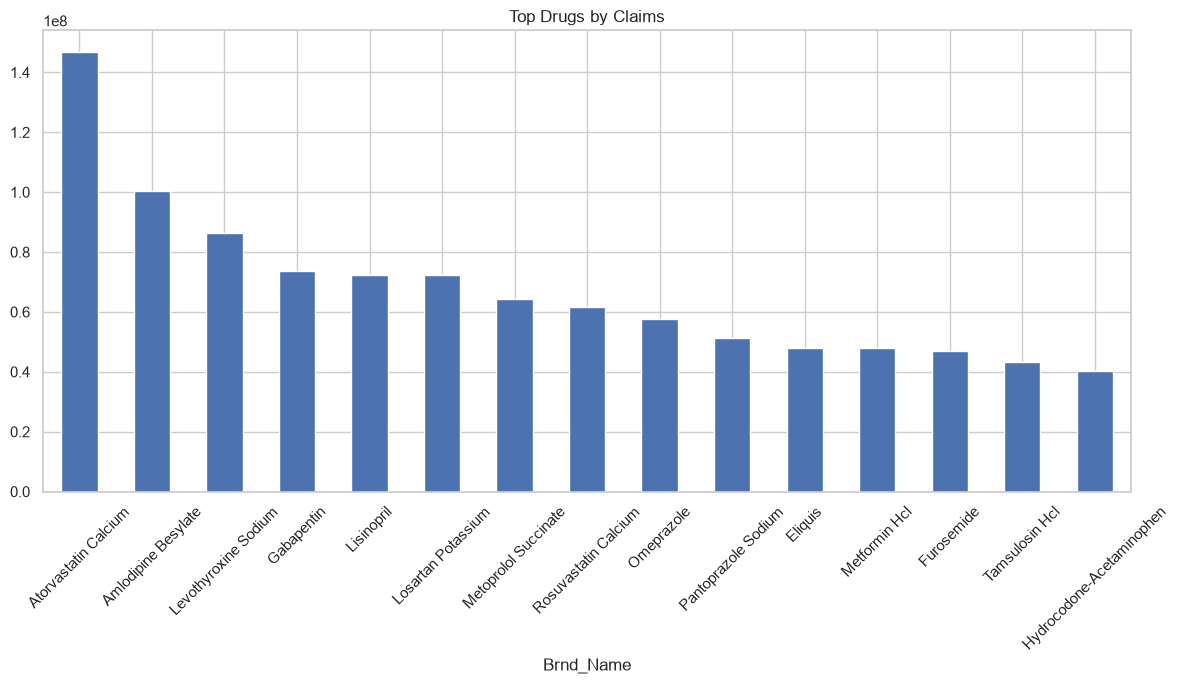

In [ ]:
# ------------------------------------------------
# Top Drugs by Claims
# ------------------------------------------------
drug = (
geography
.groupby("Brnd_Name")["Tot_Clms"]
.sum()
.sort_values(ascending=False)
.head(15)
)

plt.figure(figsize=(12,7))

drug.plot(kind="bar")

plt.title("Top Drugs by Claims")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

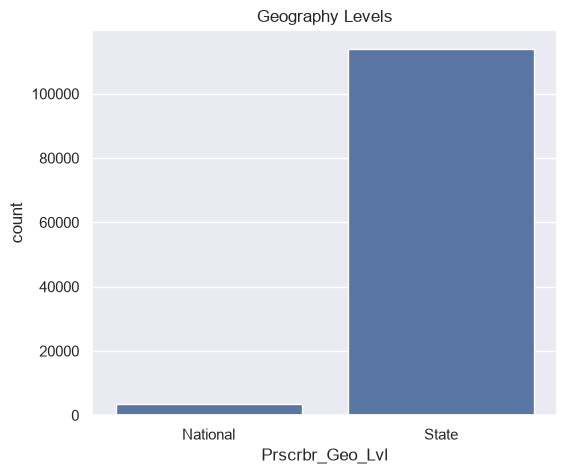

In [ ]:
# ------------------------------------------------
# Geography Level
# ------------------------------------------------
plt.figure(figsize=(6,5))

sns.countplot(

data=geography,

x="Prscrbr_Geo_Lvl"

)

plt.title("Geography Levels")

plt.show()

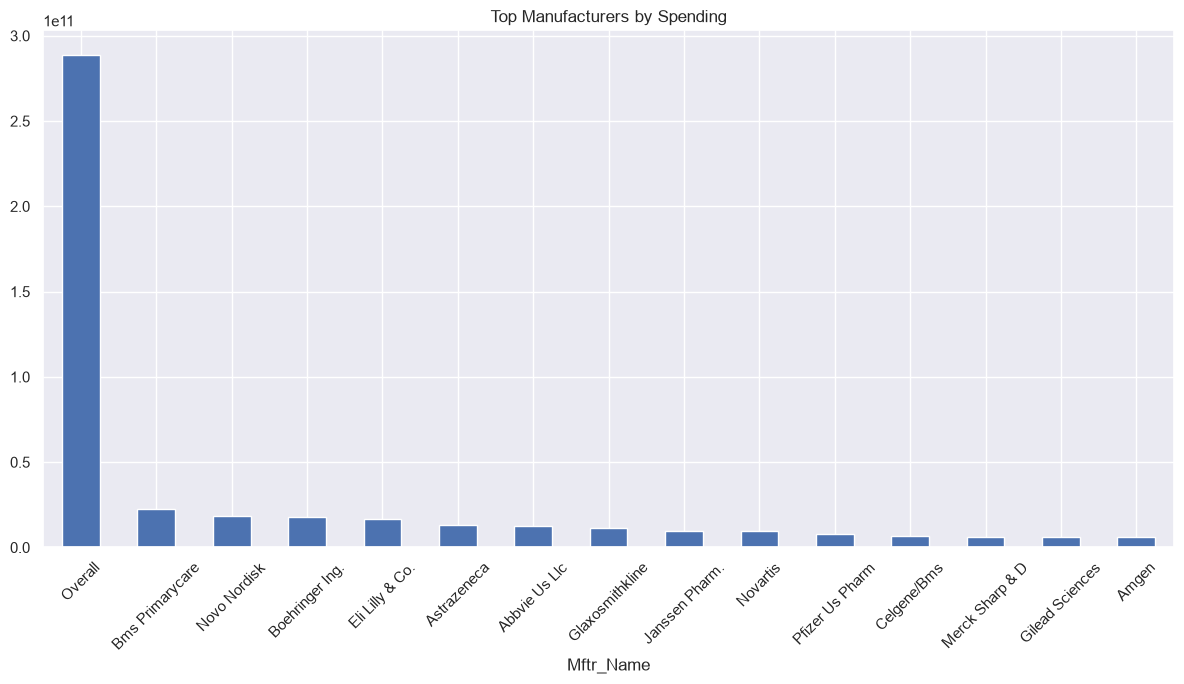

In [ ]:
# ------------------------------------------------
# Top Manufacturers
# ------------------------------------------------
manufacturer = (
spending
.groupby("Mftr_Name")["Tot_Spndng_2024"]
.sum()
.sort_values(ascending=False)
.head(15)
)

plt.figure(figsize=(12,7))

manufacturer.plot(kind="bar")

plt.title("Top Manufacturers by Spending")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

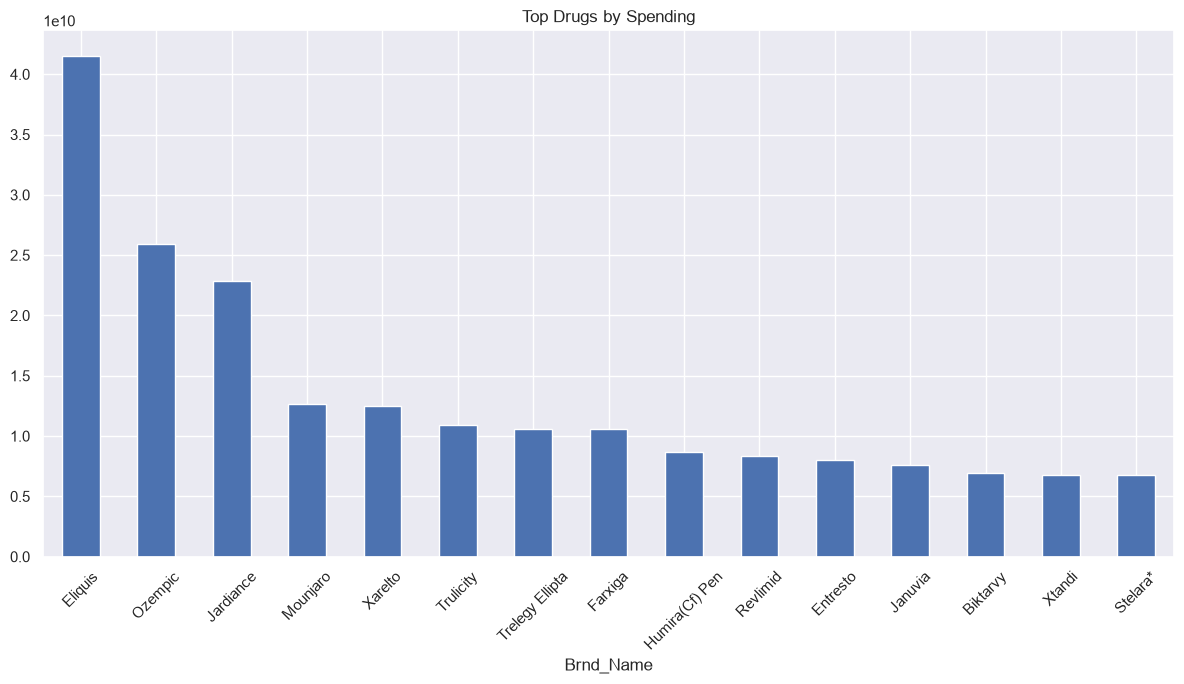

In [ ]:
# ------------------------------------------------
# Top Drugs by Spending
# ------------------------------------------------
drug = (
spending
.groupby("Brnd_Name")["Tot_Spndng_2024"]
.sum()
.sort_values(ascending=False)
.head(15)
)

plt.figure(figsize=(12,7))

drug.plot(kind="bar")

plt.title("Top Drugs by Spending")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

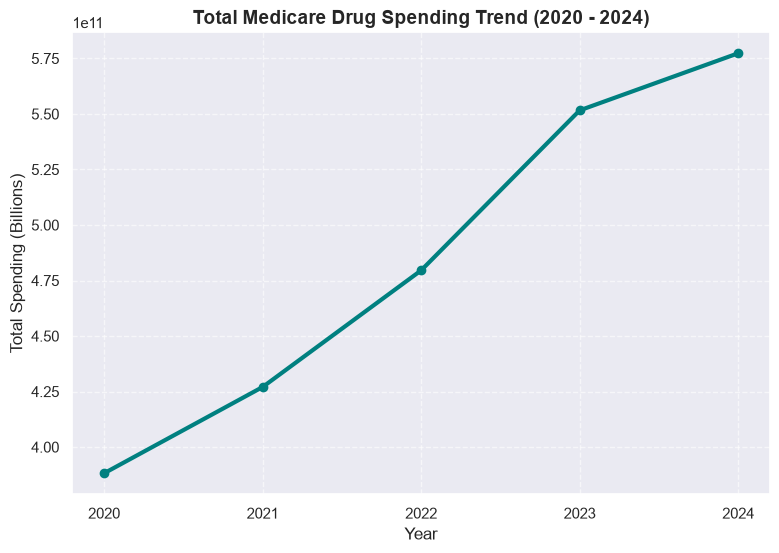

In [ ]:
# ------------------------------------------------
# Spending Trend (2020–2024)
# ------------------------------------------------
spending = pd.read_sql("""
SELECT
    "Tot_Spndng_2020",
    "Tot_Spndng_2021",
    "Tot_Spndng_2022",
    "Tot_Spndng_2023",
    "Tot_Spndng_2024"
FROM commercial.spending_features;
""", engine)


years = [2020, 2021, 2022, 2023, 2024]

spending_trend = [
    spending["Tot_Spndng_2020"].sum(),
    spending["Tot_Spndng_2021"].sum(),
    spending["Tot_Spndng_2022"].sum(),
    spending["Tot_Spndng_2023"].sum(),
    spending["Tot_Spndng_2024"].sum()
]

# Step 3: Plot the trend line
plt.figure(figsize=(9, 6))
plt.plot(years, spending_trend, marker="o", linewidth=3, color="teal")

plt.title("Total Medicare Drug Spending Trend (2020 - 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Spending (Billions)", fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

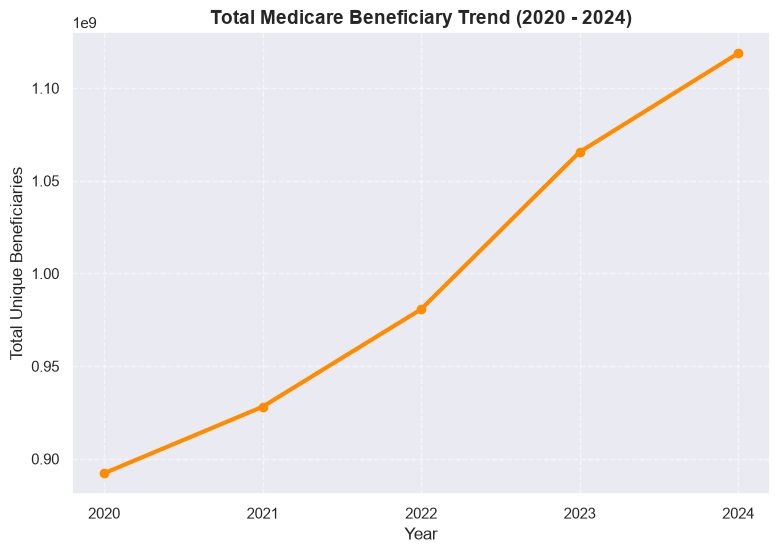

In [ ]:
# ------------------------------------------------
# Beneficiary Trend (2020–2024)
# ------------------------------------------------
spending_benes = pd.read_sql("""
SELECT
    "Tot_Benes_2020",
    "Tot_Benes_2021",
    "Tot_Benes_2022",
    "Tot_Benes_2023",
    "Tot_Benes_2024"
FROM commercial.spending_features;
""", engine)

years = [2020, 2021, 2022, 2023, 2024]

beneficiaries = [
    spending_benes["Tot_Benes_2020"].sum(),
    spending_benes["Tot_Benes_2021"].sum(),
    spending_benes["Tot_Benes_2022"].sum(),
    spending_benes["Tot_Benes_2023"].sum(),
    spending_benes["Tot_Benes_2024"].sum()
]

plt.figure(figsize=(9, 6))
plt.plot(years, beneficiaries, marker="o", linewidth=3, color="darkorange")

plt.title("Total Medicare Beneficiary Trend (2020 - 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Unique Beneficiaries", fontsize=12)
plt.xticks(years)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

#  **Pharma Business Rules & Commercial Insights** 

### Objective

This section applies pharmaceutical commercial analytics techniques that are widely used by commercial, market access, and sales strategy teams.

Unlike traditional Exploratory Data Analysis (EDA), these analyses focus on answering business questions that directly support commercial decision-making.

The objective is to identify high-value physicians, understand prescription concentration, evaluate drug performance, detect growth opportunities, and identify underperforming markets.

### <u> **Business Question 1:** </u> 

### Which drugs contribute the most to total Medicare spending?

#### Finding:

A relatively small number of drugs account for a disproportionately large share of total Medicare Part D spending, indicating that drug spending is highly concentrated.

#### Evidence:

The **Top Drug Spending Analysis** ranks drugs by total spending and demonstrates that only a limited number of products contribute significantly to overall healthcare expenditure.

#### Business Impact:

High-cost drugs have a substantial influence on commercial revenue, healthcare expenditure, pricing strategies, and reimbursement decisions.

#### Recommendation:

Commercial teams should continuously monitor these high-value drugs, optimize pricing strategies, and prioritize lifecycle management to maximize long-term commercial performance.

---

### <u> **Business Question 2:** </u> 

### Which physician specialties drive the highest prescription volume?

#### Finding:

Prescription activity is concentrated among a limited number of physician specialties, with certain specialties generating considerably higher prescription volumes.

#### Evidence:

The **Top Specialties by Prescription Volume** visualization highlights physician specialties responsible for the largest proportion of total claims.

#### Business Impact:

High-prescribing specialties represent key customer segments for pharmaceutical sales organizations and should receive greater commercial attention.

#### Recommendation:

Develop specialty-focused engagement strategies, educational initiatives, and sales campaigns targeting physicians with the greatest prescribing influence.

---

### <u> **Business Question 3:** </u> 

### Which geographic regions generate the highest prescription demand?

#### Finding:

Prescription utilization varies considerably across different states, with several regions consistently generating higher prescription volumes than others.

#### Evidence:

The **State-wise Prescription Claims Analysis** clearly identifies states with the highest commercial prescription demand.

#### Business Impact:

Geographic differences directly influence territory planning, sales force allocation, forecasting, and commercial investment decisions.

#### Recommendation:

Allocate additional commercial resources, sales representatives, and promotional activities to high-demand states while exploring growth opportunities in underperforming regions.

---

## </u> **Business Question 4:** </u> 

### Is drug spending directly related to prescription volume?

#### Finding:

Drug spending generally increases as prescription volume increases, indicating a positive relationship between utilization and overall healthcare expenditure.

#### Evidence:

The **Claims vs Drug Cost Scatter Plot** demonstrates a positive association between total prescription claims and total drug spending.

#### Business Impact:

Rapid increases in prescription demand can significantly impact future healthcare costs and pharmaceutical commercial performance.

#### Recommendation:

Monitor drugs demonstrating rapidly increasing prescription volumes to identify future commercial opportunities, pricing risks, and reimbursement challenges.

---

### <u> **Business Question 5:** </u> 

### Do a relatively small number of physicians generate most prescription activity?

#### Finding:

A relatively small percentage of physicians account for a disproportionately large share of prescription claims, demonstrating strong market concentration.

#### Evidence:

The **Top Prescribers Analysis** shows that prescription volume is concentrated among a limited group of high-performing physicians.

#### Business Impact:

These physicians have substantial influence on prescription trends and represent strategically important commercial customers.

#### Recommendation:

Implement physician segmentation strategies such as Prescriber Decile Analysis and prioritize engagement with Top Decile physicians through targeted commercial initiatives.

---

### <u> **Business Question 6:** </u> 

### Do approximately 20% of drugs contribute to nearly 80% of total spending?

#### Finding:

The Pareto Analysis indicates that a relatively small proportion of drugs contributes the majority of overall Medicare spending, supporting the Pareto (80/20) principle.

#### Evidence:

The **Pareto Chart** demonstrates cumulative spending across drugs, showing that spending is concentrated among a limited number of pharmaceutical products.

#### Business Impact:

Commercial revenue depends heavily on a small portfolio of high-performing products, increasing the importance of strategic portfolio management.

#### Recommendation:

Maintain strong commercial investment in high-contributing drugs while expanding the market potential of emerging products to diversify future revenue.

---

### <u> **Business Question 7:** </u> 

### Which drugs are growing and which are declining over time?

#### Finding:

Drug spending trends between 2020 and 2024 indicate that some products continue to experience sustained commercial growth while others show declining market performance.

#### Evidence

The **Drug Lifecycle Analysis** classifies products into Growing, Stable, and Declining categories based on multi-year spending trends.

#### Business Impact:

Understanding product lifecycle stages supports portfolio optimization, forecasting, pricing decisions, and future investment planning.

#### Recommendation:

Increase commercial investment in growing products while continuously evaluating declining products for repositioning, pricing optimization, or lifecycle extension strategies.

---

### <u> **Business Question 8:** </u> 

### Which states appear underpenetrated and may represent future commercial opportunities?

#### Finding:

Several states demonstrate comparatively lower prescription utilization and drug spending despite representing potential commercial markets.

#### Evidence:

The **Geographic Penetration Analysis** compares prescription activity across states and identifies regions with relatively lower commercial performance.

#### Business Impact:

Underperforming markets represent potential opportunities for future sales expansion, physician engagement, and market access initiatives.

#### Recommendation:

Prioritize commercial expansion efforts in underpenetrated states through targeted physician engagement programs and region-specific commercial strategies.

---

### **Key Project Insights:**

- Drug spending is highly concentrated among a relatively small number of pharmaceutical products.
- Physician prescribing behavior varies significantly across medical specialties.
- Prescription demand differs considerably across geographic regions.
- A limited number of physicians generate a substantial proportion of total prescription activity.
- Higher prescription volumes are generally associated with higher drug spending.
- Commercial revenue is concentrated among a limited portfolio of high-value drugs.
- Drug lifecycle analysis identifies products with strong future commercial potential.
- Geographic penetration analysis reveals opportunities for commercial market expansion.


---

### **Project Conclusion:**

This project demonstrates how Medicare Part D prescription, physician, geographic, and drug spending data can be transformed into meaningful commercial intelligence using SQL, Python, and Power BI.

By integrating data engineering, feature engineering, exploratory data analysis, pharmaceutical business rules, and interactive visualization, the project provides actionable insights that support physician targeting, commercial strategy, territory planning, portfolio optimization, and market access decision-making.

The resulting analytics solution closely reflects the workflow followed by commercial analytics teams within leading pharmaceutical organizations and demonstrates how data-driven insights can support strategic business decisions.